# DigiCow Farmer Adoption Prediction

**Competition:** DigiCow Farmer Adoption Prediction - Zindi Africa
**Goal:** Predict the probability that a farmer adopts an agricultural practice

within 7, 90, and 120 days of attending a training session, using only
information available at the time of training.

**Approach:** We build interpretable models that produce probability scores
for each prediction window. The focus throughout is on features and decisions
that can be explained to a non-technical audience.

---

### Data Available

| File | Description |
|---|---|
| `Train.csv` | Labelled training records: farmers with known adoption outcomes |
| `Test.csv` | Unlabelled records: farmers whose adoption we predict |
| `Prior.csv` | Historical training records from an earlier period: used for feature construction |

### Notebook Structure

| Section | Content |
|---|---|
| 1 | Data loading and sanity checks |
| 2 | Exploratory data analysis |
| 3 | Feature engineering |
| 4 | Logistic Regression models with odds ratios |
| 5 | Decision Tree models with visualisation |
| 6 | Classifier Chain - exploiting target structure |
| 7 | Model comparison |
| 8 | Interpretation |

### Libraries 

`pandas` is used throughout this notebook for data manipulation. All datasets are loaded and processed as `pandas` DataFrames.

`numpy` supports numerical operations used in feature engineering and metric calculations.

`matplotlib` is the base plotting library. All charts in this notebook are built using `matplotlib` figures and axis

`seaborn` sits on top of `matplotlib` and simplifies grouped bar charts and heatmaps. 

`os` is used to create the figures folder if it does not already exist.

`ast` is used to parse the topics column, which is stored as a string
representation of a Python list.

In [60]:
# ── Libraries ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# ── Output folder ─────────────────────────────────────────────────────────────
# All charts are saved here so they can be referenced in the README.
os.makedirs('figures', exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
# Any function that involves randomness accepts a random_state parameter.
# Passing the same integer every time ensures results are identical across runs.
RANDOM_SEED = 42



# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_rows', 100)

print("Libraries loaded.")


Libraries loaded.


## 1. Data Loading and Initial Overview

We load all three files and verify they match expectations. This section establishes that the data is intact and that the relationship between the three files is what we expect.

The three files serve different purposes:
- `Train.csv` is used to train the models, it contains known outcomes
- `Test.csv` contains farmers whose adoption we need to predict
- `Prior.csv` contains historical records from an earlier period. We will use this in Section 3 to build features without leaking information about the outcomes we are predicting

In [61]:
train_df = pd.read_csv('Train.csv')
test_df = pd.read_csv('Test.csv')
prior_df = pd.read_csv('Prior.csv')

print("Files loaded.")
print(f"  Train : {train_df.shape[0]:,} rows  {train_df.shape[1]} columns")
print(f"  Test  : {test_df.shape[0]:,} rows  {test_df.shape[1]} columns")
print(f"  Prior : {prior_df.shape[0]:,} rows  {prior_df.shape[1]} columns")

Files loaded.
  Train : 13,536 rows  17 columns
  Test  : 5,621 rows  14 columns
  Prior : 44,882 rows  17 columns


In [62]:
print("=== TEST COLUMNS ===")
for col in test_df.columns:
    print(f"  {col}")
print(f"Shape: {test_df.shape}")

print("=== TRAIN COLUMNS ===")
for col in train_df.columns:
    print(f"  {col}")
print(f"Shape: {train_df.shape}")

print("\n=== PRIOR COLUMNS ===")
for col in prior_df.columns:
    print(f"  {col}")
print(f"Shape: {prior_df.shape}")

print("\n=== PRIOR SAMPLE ===")
print(prior_df.head(3).to_string())

=== TEST COLUMNS ===
  ID
  farmer_name
  training_day
  gender
  registration
  age
  group_name
  belong_to_cooperative
  county
  subcounty
  ward
  has_topic_trained_on
  trainer
  topics_list
Shape: (5621, 14)
=== TRAIN COLUMNS ===
  ID
  farmer_name
  training_day
  gender
  registration
  age
  group_name
  belong_to_cooperative
  county
  subcounty
  ward
  adopted_within_07_days
  adopted_within_90_days
  adopted_within_120_days
  has_topic_trained_on
  trainer
  topics_list
Shape: (13536, 17)

=== PRIOR COLUMNS ===
  ID
  farmer_name
  training_day
  gender
  registration
  age
  group_name
  belong_to_cooperative
  county
  subcounty
  ward
  adopted_within_07_days
  adopted_within_90_days
  adopted_within_120_days
  has_topic_trained_on
  trainer
  topics_list
Shape: (44882, 17)

=== PRIOR SAMPLE ===
          ID  farmer_name training_day  gender registration       age   group_name  belong_to_cooperative      county    subcounty          ward  adopted_within_07_days  adopte

### 1.3 Data Types and Missing Values

We inspect each dataset for two things:

(i) how each column is stored

(ii) whether any values are missing. 


In [63]:
print("=== Train ===")
train_df.info()

print("\n=== Test ===")
test_df.info()

print("\n=== Prior ===")
prior_df.info()

=== Train ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13536 entries, 0 to 13535
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       13536 non-null  object
 1   farmer_name              13536 non-null  object
 2   training_day             13536 non-null  object
 3   gender                   13536 non-null  object
 4   registration             13536 non-null  object
 5   age                      13536 non-null  object
 6   group_name               13536 non-null  object
 7   belong_to_cooperative    13536 non-null  int64 
 8   county                   13536 non-null  object
 9   subcounty                13536 non-null  object
 10  ward                     13536 non-null  object
 11  adopted_within_07_days   13536 non-null  int64 
 12  adopted_within_90_days   13536 non-null  int64 
 13  adopted_within_120_days  13536 non-null  int64 
 14  has_topic_trained_on    

In [64]:
# Checking for missing values in train and test datasets
print("=== Missing Values — Train ===")
missing = train_df.isnull().sum() # counts missing values per column
missing_pct = (missing / len(train_df) * 100).round(2) # Percentage of missing values per column
print(pd.DataFrame({'missing_count': missing,
                    'missing_pct': missing_pct})
      [missing > 0])

print("\n=== Missing Values — Test ===")
missing = test_df.isnull().sum()
missing_pct = (missing / len(test_df) * 100).round(2)
print(pd.DataFrame({'missing_count': missing,
                    'missing_pct': missing_pct})
      [missing > 0])

=== Missing Values — Train ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

=== Missing Values — Test ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


No missing values were found in either Train or Test. This means every row is complete and no imputation is needed before modelling.

In [65]:
# Check exact values in the registration column
print(train_df['registration'].value_counts())

# Check the topics_list — first 3 values
print()
for val in train_df['topics_list'].head(3):
    print(val)
    print()

# Check Prior adoption column name and a sample
print(prior_df[['trainer', 'county', 'adopted_within_120_days']].head(3))

registration
Ussd      8383
Manual    5153
Name: count, dtype: int64

[['Ndume App', 'Poultry Feeding']]

[['Poultry Housing'], ['Poultry Housing']]

[['Asili Fertilizer (Organic)', 'Biosecurity In Poultry Farming', 'Calf Feeding', 'Dairy Health Management', 'Dairy Nutrition With Tyari', 'Diseases In Dairy Farming', 'Feeding A Lactating Cow', 'How To Feed Kienyeji Chicken For Meat', 'How To Feed Kienyeji Chicken From 1 Day Old To Maturity', 'How To Feed Layers From 1 Day Old To Maturity', 'How To Rear A Calf With Unga Products', 'How To Rear Healthy Chicken With Biodeal.', 'Importance Of Choosing The Right Seed Variety', 'Importance Of Vaccinations And Record', 'Milking Hygiene', 'Personal Protective Equipment (Ppe)', 'Pest And Disease Management In Maize And Beans', 'Poultry And Dairy Feeding With Tyari Feeds', 'Poultry Diseases And Biosecurity', 'Poultry Feeding', 'Poultry Feeding With Tyari', 'Poultry Health Management', 'Poultry Housing', 'Poultry Products', 'Record Keeping In Dair

In [66]:
# ── Reusable summary function ─────────────────────────────────────────────────
# Defined once, called on all three DataFrames

def summarise_dataframe(df, name):
    """
    Returns a column-level audit table.
    
    Parameters
    ----------
    df   : pd.DataFrame
    name : str — label for the printed header
    """
    summary = pd.DataFrame({
        'dtype'         : df.dtypes,
        'missing_count' : df.isnull().sum(),
        'missing_pct'   : (df.isnull().sum() / len(df) * 100).round(2),
        'n_unique'      : df.nunique(),
        'has_missing'   : df.isnull().sum() > 0
    })

    print(f"\n{'═' * 60}")
    print(f"  {name}  |  {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
    print(f"{'═' * 60}")
    return summary

train_summary = summarise_dataframe(train_df, "Train.csv")
display(train_summary)

test_summary = summarise_dataframe(test_df, "Test.csv")
display(test_summary)

prior_summary = summarise_dataframe(prior_df, "Prior.csv")
display(prior_summary)


════════════════════════════════════════════════════════════
  Train.csv  |  13,536 rows  ×  17 columns
════════════════════════════════════════════════════════════


,dtype,missing_count,missing_pct,n_unique,has_missing
ID,object,0,0.0000,13536,False
farmer_name,object,0,0.0000,13536,False
training_day,object,0,0.0000,152,False
gender,object,0,0.0000,2,False
registration,object,0,0.0000,2,False
age,object,0,0.0000,2,False
group_name,object,0,0.0000,864,False
belong_to_cooperative,int64,0,0.0000,2,False
county,object,0,0.0000,8,False
subcounty,object,0,0.0000,26,False



════════════════════════════════════════════════════════════
  Test.csv  |  5,621 rows  ×  14 columns
════════════════════════════════════════════════════════════


,dtype,missing_count,missing_pct,n_unique,has_missing
ID,object,0,0.0000,5621,False
farmer_name,object,0,0.0000,5621,False
training_day,object,0,0.0000,78,False
gender,object,0,0.0000,2,False
registration,object,0,0.0000,2,False
age,object,0,0.0000,2,False
group_name,object,0,0.0000,239,False
belong_to_cooperative,int64,0,0.0000,2,False
county,object,0,0.0000,7,False
subcounty,object,0,0.0000,16,False



════════════════════════════════════════════════════════════
  Prior.csv  |  44,882 rows  ×  17 columns
════════════════════════════════════════════════════════════


,dtype,missing_count,missing_pct,n_unique,has_missing
ID,object,0,0.0000,44882,False
farmer_name,object,0,0.0000,6719,False
training_day,object,0,0.0000,224,False
gender,object,0,0.0000,2,False
registration,object,0,0.0000,2,False
age,object,0,0.0000,2,False
group_name,object,0,0.0000,840,False
belong_to_cooperative,int64,0,0.0000,2,False
county,object,0,0.0000,9,False
subcounty,object,0,0.0000,28,False


In [67]:
# ── Clean trainer column ──────────────────────────────────────────────────────
# A small number of rows have multiple trainers stored as a list string
# We extract only the first trainer for simplicity
import ast

def extract_first_trainer(val):
    """
    Extract first trainer from value.
    Handles both plain strings like 'TRA_abc' 
    and list strings like "['TRA_abc', 'TRA_xyz']"
    """
    if pd.isna(val):
        return val
    try:
        parsed = ast.literal_eval(str(val))
        if isinstance(parsed, list):
            return parsed[0]   # take first trainer only
    except:
        pass
    return str(val)

# Apply to all three dataframes
train_df['trainer'] = train_df['trainer'].apply(extract_first_trainer)
test_df['trainer']  = test_df['trainer'].apply(extract_first_trainer)
prior_df['trainer'] = prior_df['trainer'].apply(extract_first_trainer)

# Verify
print("Unique trainers in Train:", train_df['trainer'].nunique())
print("Sample values:", train_df['trainer'].unique()[:5])

Unique trainers in Train: 9
Sample values: ['TRA_szrwyfzz' 'TRA_rkvyofbh' 'TRA_gertumxc' 'TRA_hyodnntj'
 'TRA_suiifsur']


## 2. Exploratory Data Analysis

Before building any model we examine the data to understand patterns and 
identify which features are likely to be predictive. All findings here 
directly inform the feature engineering decisions in Section 3.

### 2.1 Target Distribution

The three targets are severely imbalanced; very few farmers adopt within 
any time window. We quantify this imbalance before modelling because it 
directly affects which models and evaluation metrics we use.

In [68]:
# ── 2.1 Target Distribution ───────────────────────────────────────────────────
TARGET_COLS = [
    'adopted_within_07_days',
    'adopted_within_90_days',
    'adopted_within_120_days'
]

# Count adopters and non-adopters per target
target_summary = []
for col in TARGET_COLS:
    total        = len(train_df)
    adopted      = train_df[col].sum()
    not_adopted  = total - adopted
    rate         = adopted / total * 100
    ratio        = not_adopted / adopted

    target_summary.append({
        'Target'          : col.replace('adopted_within_', '').replace('_days', 'd'),
        'Total'           : total,
        'Adopted'         : adopted,
        'Not Adopted'     : not_adopted,
        'Adoption Rate %' : round(rate, 2),
        'Imbalance Ratio' : f'{ratio:.0f}:1'
    })

summary_df = pd.DataFrame(target_summary).set_index('Target')
display(summary_df)

,Total,Adopted,Not Adopted,Adoption Rate %,Imbalance Ratio
Target,,,,,
07d,13536,153,13383,1.1300,87:1
90d,13536,214,13322,1.5800,62:1
120d,13536,302,13234,2.2300,44:1


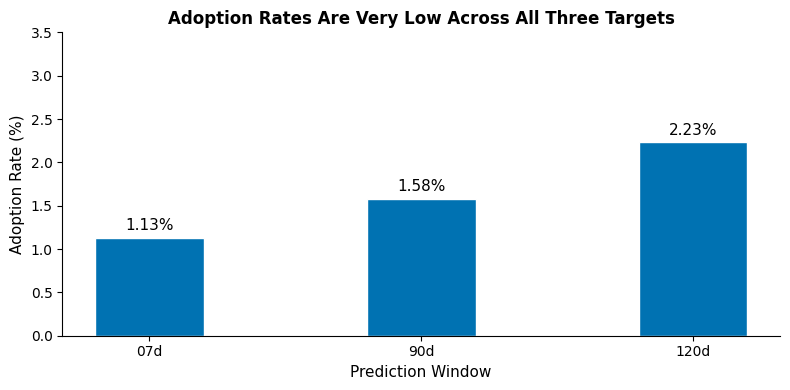

Chart saved to figures/01_target_distribution.png


In [69]:
# ── Chart: Adoption rates across three targets ────────────────────────────────
# Wong colorblind-safe palette
BLUE      = '#0072B2'
VERMILLION = '#D55E00'
GREEN     = '#009E73'

fig, ax = plt.subplots(figsize=(8, 4))

targets  = ['07d', '90d', '120d']
rates    = [1.13, 1.58, 2.23]
colours  = [BLUE, BLUE, BLUE]

bars = ax.bar(targets, rates, color=colours, width=0.4, edgecolor='white')

# Add value labels on top of each bar
for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{rate}%',
        ha='center', va='bottom', fontsize=11
    )

ax.set_xlabel('Prediction Window', fontsize=11)
ax.set_ylabel('Adoption Rate (%)', fontsize=11)
ax.set_title('Adoption Rates Are Very Low Across All Three Targets',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 3.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to figures/01_target_distribution.png")

### 2.2 Adoption Rates by Key Features

We examine how adoption rates vary across four categorical features:
gender, age group, registration method and cooperative membership.
Features with large differences between categories are likely to be
useful predictors.

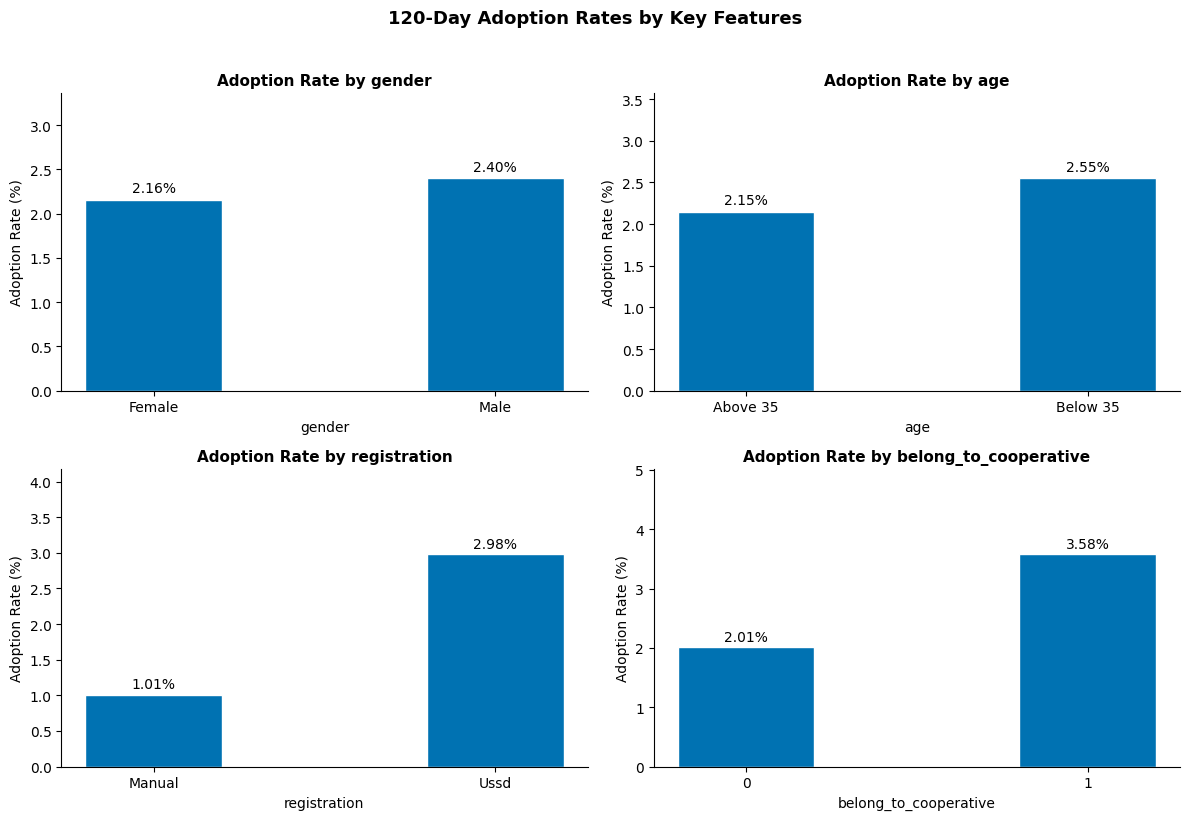

Chart saved.


In [70]:
# ── 2.2 Adoption rates by categorical features ───────────────────────────────
# Features to examine
CAT_FEATURES = ['gender', 'age', 'registration', 'belong_to_cooperative']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(CAT_FEATURES):
    # Calculate mean adoption rate per category for 120-day target
    rates = (train_df.groupby(feature)['adopted_within_120_days']
             .mean()
             .mul(100)
             .round(2)
             .reset_index())
    rates.columns = ['category', 'adoption_rate']

    # Plot
    axes[i].bar(
        rates['category'].astype(str),
        rates['adoption_rate'],
        color=BLUE,
        edgecolor='white',
        width=0.4
    )

    # Value labels
    for bar in axes[i].patches:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{bar.get_height():.2f}%',
            ha='center', va='bottom', fontsize=10
        )

    axes[i].set_title(f'Adoption Rate by {feature}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Adoption Rate (%)', fontsize=10)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylim(0, rates['adoption_rate'].max() * 1.4)
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('120-Day Adoption Rates by Key Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/02_adoption_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

Cooperative membership and registration method show the strongest association
with adoption. Farmers who belong to a cooperative adopt at 78% higher rates
than non-members. USSD-registered farmers adopt at nearly three times the rate
of manually registered farmers. Gender and age show minimal differences and
are unlikely to be strong predictors.

### 2.3 Trainer Effectiveness

Adoption rates vary significantly across trainers. A trainer who consistently
achieves higher adoption rates is a strong signal worth capturing. We examine
this variation here to justify using trainer historical rates as a feature.

     trainer  farmer_count  adoption_rate
TRA_kkzpfdtu           734         5.3100
TRA_szrwyfzz          2028         4.6400
TRA_twwcfcum            24         4.1700
TRA_rkvyofbh          1877         3.6800
TRA_hyodnntj          2168         2.9100
TRA_gertumxc          3049         0.7900
TRA_ubcgvofe          1456         0.6200
TRA_suiifsur          2190         0.1400
TRA_dttdgplk            10         0.0000


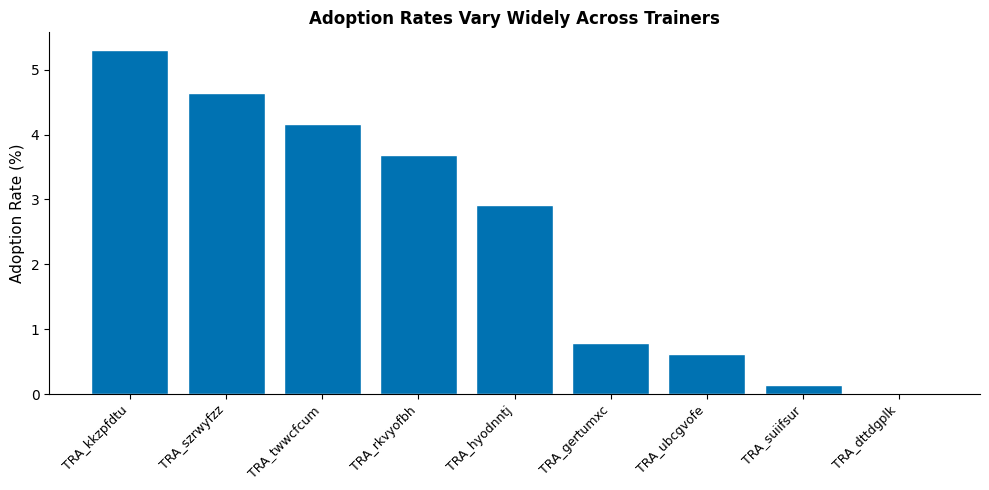

In [42]:
# ── 2.3 Trainer effectiveness ─────────────────────────────────────────────────
trainer_stats = (train_df.groupby('trainer')
                 .agg(
                     farmer_count   = ('ID', 'count'),
                     adoption_rate  = ('adopted_within_120_days', 'mean')
                 )
                 .reset_index())

trainer_stats['adoption_rate'] = (trainer_stats['adoption_rate'] * 100).round(2)

# Sort by adoption rate
trainer_stats = trainer_stats.sort_values('adoption_rate', ascending=False)

print(trainer_stats.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    range(len(trainer_stats)),
    trainer_stats['adoption_rate'],
    color=BLUE,
    edgecolor='white'
)

ax.set_xticks(range(len(trainer_stats)))
ax.set_xticklabels(trainer_stats['trainer'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Adoption Rate (%)', fontsize=11)
ax.set_title('Adoption Rates Vary Widely Across Trainers',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/03_trainer_effectiveness.png', dpi=150, bbox_inches='tight')
plt.show()

Trainer identity shows considerable variation in adoption rates, ranging 
from 5.31% for the most effective trainer to near zero for the least 
effective. This suggests that trainer quality or style meaningfully 
influences whether farmers adopt practices. We will encode this as a 
smoothed historical rate in Section 3 rather than as a dummy variable, 
to avoid creating sparse columns for trainers with few records.

### 2.4 County-Level Adoption Patterns

Adoption rates vary across counties. Since county identity may reflect 
differences in agricultural culture, trainer assignment, or cooperative 
density, it is worth examining as a potential predictor.

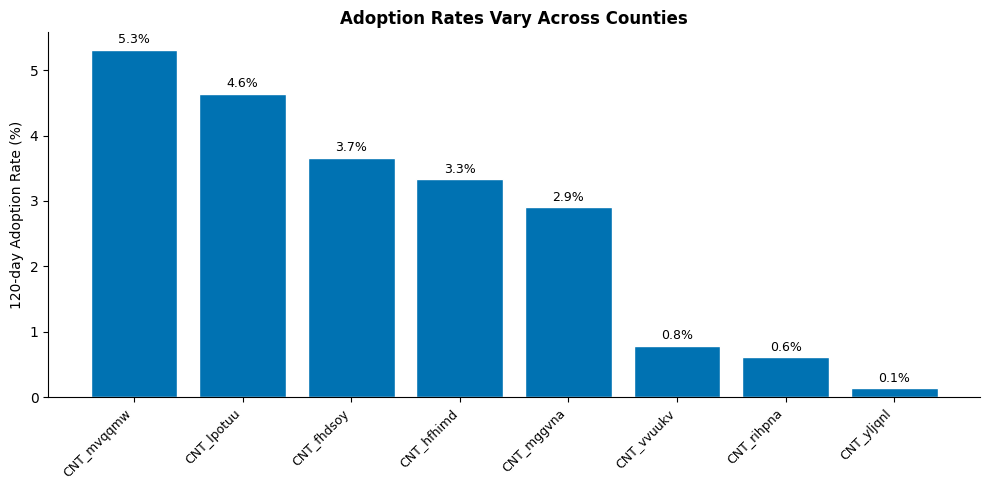

,county,farmer_count,rate_120
0,CNT_mvqqmw,734,5.3100
1,CNT_lpotuu,2028,4.6400
2,CNT_fhdsoy,1887,3.6600
3,CNT_hfhimd,30,3.3300
4,CNT_mggvna,2168,2.9100
5,CNT_vvuukv,3049,0.7900
6,CNT_rihpna,1450,0.6200
7,CNT_yljqnl,2190,0.1400


In [43]:
# ── 2.4 County adoption rates ─────────────────────────────────────────────────
county_stats = (train_df.groupby('county')
                .agg(
                    farmer_count=('ID', 'count'),
                    rate_120=('adopted_within_120_days', 'mean')
                )
                .reset_index())

county_stats['rate_120'] = (county_stats['rate_120'] * 100).round(2)
county_stats = county_stats.sort_values('rate_120', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    range(len(county_stats)),
    county_stats['rate_120'],
    color=BLUE,
    edgecolor='white'
)

# Value labels
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=9
    )

ax.set_xticks(range(len(county_stats)))
ax.set_xticklabels(county_stats['county'], rotation=45,
                   ha='right', fontsize=9)
ax.set_ylabel('120-day Adoption Rate (%)', fontsize=10)
ax.set_title('Adoption Rates Vary Across Counties',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/04_county_adoption.png', dpi=150, bbox_inches='tight')
plt.show()

display(county_stats.reset_index(drop=True))

County-level adoption rates range from 5.31% to 0.14%, which is a 37x  difference. The pattern closely mirrors the trainer effectiveness 
results, which suggests that trainer assignment and county are 
correlated. Counties with few farmers produce unreliable raw rates. 


### 2.5 Topic Analysis

Each training session covers one or more topics. We examine how many 
topics are covered per session and which individual topics are 
associated with higher adoption rates.

In [44]:
# ── 2.5 Topic analysis ────────────────────────────────────────────────────────
import ast

def parse_topics(topic_str):
    """
    Parse topics_list string into a flat deduplicated list of topic strings.
    Handles nested list format: [['topic1', 'topic2'], ['topic1']]
    Deduplicates within a single session.
    """
    if pd.isna(topic_str):
        return []
    try:
        parsed = ast.literal_eval(str(topic_str))
        flat = []
        for item in parsed:
            if isinstance(item, list):
                flat.extend([t.strip() for t in item])
            else:
                flat.append(str(item).strip())
        return list(set(flat))   # deduplicate within session
    except:
        return []

# Parse topics for train
train_topics = train_df['topics_list'].apply(parse_topics)

# Topic count per session
train_df['n_topics'] = train_topics.apply(len)

print("Topics per session:")
print(train_df['n_topics'].describe().round(2))

Topics per session:
count   13536.0000
mean        3.0100
std         2.2300
min         1.0000
25%         2.0000
50%         3.0000
75%         4.0000
max        33.0000
Name: n_topics, dtype: float64


In [45]:
# ── Topic adoption rates ──────────────────────────────────────────────────────
# For each unique topic find how many farmers were trained on it
# and what proportion adopted within 120 days

from collections import Counter

# Build one row per farmer-topic pair
topic_records = []
for idx, topics in train_topics.items():
    outcome = train_df.loc[idx, 'adopted_within_120_days']
    for topic in topics:
        topic_records.append({
            'topic'   : topic,
            'adopted' : outcome
        })

topic_df = pd.DataFrame(topic_records)

# Aggregate per topic
topic_stats = (topic_df.groupby('topic')
               .agg(
                   farmer_count=('adopted', 'count'),
                   adoption_rate=('adopted', 'mean')
               )
               .reset_index())

# Keep only topics with at least 20 farmers
topic_stats = topic_stats[topic_stats['farmer_count'] >= 20].copy()
topic_stats['adoption_rate'] = (topic_stats['adoption_rate'] * 100).round(2)
topic_stats = topic_stats.sort_values('adoption_rate', ascending=False)

# Show top 15
print("Top 15 topics by 120-day adoption rate:")
display(topic_stats.head(15).reset_index(drop=True))

Top 15 topics by 120-day adoption rate:


,topic,farmer_count,adoption_rate
0,Poultry Health With Biodeal,74,24.3200
1,Livestock Management Practices,40,17.5000
2,Deworming And Record Keeping In Animal Health,423,13.9500
3,Why You Should Vaccinate Your Animals,425,13.4100
4,Herd. Health. Management,481,11.6400
5,Diseases In Dairy Farming,739,11.1000
6,Importance Of Mineral Supplementation,239,10.8800
7,Poultry Health Management,772,10.4900
8,Dairy Health Management,805,10.3100
9,Poultry Health Management. Practices,446,9.1900


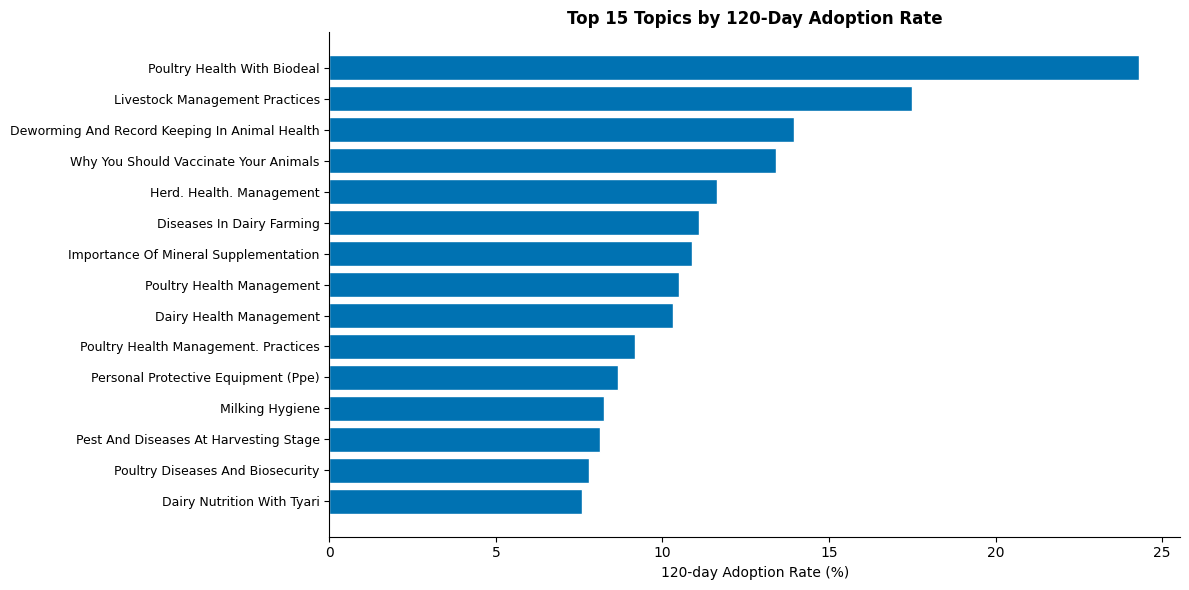

In [46]:
# ── Chart: Top 15 topics ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

top15 = topic_stats.head(15)

ax.barh(
    range(len(top15)),
    top15['adoption_rate'],
    color=BLUE,
    edgecolor='white'
)

ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['topic'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('120-day Adoption Rate (%)', fontsize=10)
ax.set_title('Top 15 Topics by 120-Day Adoption Rate',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/05_topic_adoption.png', dpi=150, bbox_inches='tight')
plt.show()

Topic content is strongly associated with adoption. Health-focused topics such as poultry health, deworming and vaccination consistently show the highest adoption rates with most exceeding 10%. This likely reflects that health interventions produce visible results quickly, giving farmers immediate motivation to adopt. We encode topic content as a smoothed historical adoption rate in Section 3.

## 3. Feature Engineering

We construct six features from the available data. Two are direct binary 
flags from Train. Four are derived from Prior.csv. Using Prior for rate-based features ensures no information about the training outcomes leaks into our features.

### 3.1 Binary Flags

Two features are created directly from Train columns.
`belong_to_cooperative` is already stored as 0 and 1 — no transformation needed.
`is_ussd_registered` is recoded from the registration column — 1 for Ussd, 0 for Manual.

In [47]:
# ── 3.1 Binary flags ──────────────────────────────────────────────────────────

# belong_to_cooperative is already 0/1 — confirm and use directly
print("belong_to_cooperative value counts:")
print(train_df['belong_to_cooperative'].value_counts())

# is_ussd_registered — 1 if registered via Ussd, 0 if Manual
# .eq('Ussd') returns True/False, .astype(int) converts to 1/0
train_df['is_ussd_registered'] = train_df['registration'].eq('Ussd').astype(int)
test_df['is_ussd_registered']  = test_df['registration'].eq('Ussd').astype(int)

print("\nis_ussd_registered value counts:")
print(train_df['is_ussd_registered'].value_counts())

print("\nSanity check — should match registration counts:")
print(train_df['registration'].value_counts())

belong_to_cooperative value counts:
belong_to_cooperative
0    11608
1     1928
Name: count, dtype: int64

is_ussd_registered value counts:
is_ussd_registered
1    8383
0    5153
Name: count, dtype: int64

Sanity check — should match registration counts:
registration
Ussd      8383
Manual    5153
Name: count, dtype: int64


### 3.2 Bayesian Smoothed Rates from Prior

We compute smoothed historical adoption rates for trainers, counties 
and topics using Prior.csv. Raw rates from small groups are unreliable — 
Bayesian smoothing pulls them toward the global mean proportionally to 
how few records they have. Groups not seen in Prior receive the global 
mean as a fallback.

In [48]:
# ── 3.2 Bayesian smoothed rates ───────────────────────────────────────────────

# Smoothing strength — higher α = more shrinkage toward global mean
ALPHA = 10

# Global adoption rate from Prior — our baseline for unseen groups
GLOBAL_RATE = prior_df['adopted_within_120_days'].mean()
print(f"Global adoption rate in Prior: {GLOBAL_RATE:.4f} ({GLOBAL_RATE*100:.2f}%)")

def compute_smoothed_rate(prior_df, group_col, target_col, alpha, global_rate):
    """
    Compute Bayesian smoothed adoption rate per group.
    
    Parameters
    ----------
    prior_df    : DataFrame containing historical records
    group_col   : column to group by e.g. 'trainer'
    target_col  : adoption outcome column e.g. 'adopted_within_120_days'
    alpha       : smoothing strength — higher means more shrinkage
    global_rate : fallback rate for unseen groups
    
    Returns
    -------
    dict mapping group value to smoothed rate
    """
    # Count adoptions and total records per group
    group_stats = (prior_df.groupby(group_col)[target_col]
                   .agg(['sum', 'count'])
                   .reset_index())
    group_stats.columns = [group_col, 'n_adopted', 'n_trained']

    # Apply smoothing formula
    group_stats['smoothed_rate'] = (
        (group_stats['n_adopted'] + alpha * global_rate) /
        (group_stats['n_trained'] + alpha)
    )

    # Convert to dictionary for fast lookup
    return dict(zip(group_stats[group_col], group_stats['smoothed_rate']))

# Compute smoothed rates for trainer and county
trainer_rate_map = compute_smoothed_rate(
    prior_df, 'trainer', 'adopted_within_120_days', ALPHA, GLOBAL_RATE
)

county_rate_map = compute_smoothed_rate(
    prior_df, 'county', 'adopted_within_120_days', ALPHA, GLOBAL_RATE
)

print(f"\nTrainer smoothed rates:")
for trainer, rate in sorted(trainer_rate_map.items(),
                             key=lambda x: x[1], reverse=True):
    print(f"  {trainer}: {rate*100:.2f}%")

print(f"\nCounty smoothed rates:")
for county, rate in sorted(county_rate_map.items(),
                            key=lambda x: x[1], reverse=True):
    print(f"  {county}: {rate*100:.2f}%")

Global adoption rate in Prior: 0.0465 (4.65%)

Trainer smoothed rates:
  TRA_dttdgplk: 10.46%
  TRA_rkvyofbh: 9.78%
  TRA_kkzpfdtu: 8.66%
  TRA_gertumxc: 4.27%
  TRA_twwcfcum: 3.58%
  TRA_szrwyfzz: 2.52%
  TRA_hyodnntj: 2.25%
  TRA_ubcgvofe: 0.68%
  TRA_suiifsur: 0.21%

County smoothed rates:
  CNT_fhdsoy: 9.79%
  CNT_mvqqmw: 8.66%
  CNT_vvuukv: 4.27%
  CNT_fnywiv: 4.23%
  CNT_lpotuu: 2.52%
  CNT_mggvna: 2.25%
  CNT_rihpna: 0.71%
  CNT_hfhimd: 0.33%
  CNT_yljqnl: 0.21%


In [49]:
# ── Apply smoothed rates to Train and Test ────────────────────────────────────
# .map() looks up each value in the dictionary
# .fillna(GLOBAL_RATE) handles any values not found in Prior

train_df['trainer_rate_smoothed'] = (train_df['trainer']
                                     .map(trainer_rate_map)
                                     .fillna(GLOBAL_RATE))

test_df['trainer_rate_smoothed']  = (test_df['trainer']
                                     .map(trainer_rate_map)
                                     .fillna(GLOBAL_RATE))

train_df['county_rate_smoothed']  = (train_df['county']
                                     .map(county_rate_map)
                                     .fillna(GLOBAL_RATE))

test_df['county_rate_smoothed']   = (test_df['county']
                                     .map(county_rate_map)
                                     .fillna(GLOBAL_RATE))

# Verify no missing values
print("Missing in trainer_rate_smoothed (train):",
      train_df['trainer_rate_smoothed'].isna().sum())
print("Missing in county_rate_smoothed (train):",
      train_df['county_rate_smoothed'].isna().sum())
print("Missing in trainer_rate_smoothed (test):",
      test_df['trainer_rate_smoothed'].isna().sum())
print("Missing in county_rate_smoothed (test):",
      test_df['county_rate_smoothed'].isna().sum())

Missing in trainer_rate_smoothed (train): 0
Missing in county_rate_smoothed (train): 0
Missing in trainer_rate_smoothed (test): 0
Missing in county_rate_smoothed (test): 0


### 3.3 Topic Smoothed Rates

Each session covers multiple topics. We compute a smoothed adoption 
rate for each individual topic from Prior, then assign each farmer 
the mean smoothed rate across all topics in their session. This 
captures topic content as a single interpretable number.

In [50]:
# ── 3.3 Topic smoothed rates ──────────────────────────────────────────────────

# Step 1: Parse topics for Prior
prior_topics = prior_df['topics_list'].apply(parse_topics)

# Step 2: Build one row per farmer-topic pair in Prior
prior_topic_records = []
for idx, topics in prior_topics.items():
    outcome = prior_df.loc[idx, 'adopted_within_120_days']
    for topic in topics:
        prior_topic_records.append({
            'topic'   : topic,
            'adopted' : outcome
        })

prior_topic_df = pd.DataFrame(prior_topic_records)

# Step 3: Compute smoothed rate per topic
topic_stats_prior = (prior_topic_df.groupby('topic')['adopted']
                     .agg(['sum', 'count'])
                     .reset_index())
topic_stats_prior.columns = ['topic', 'n_adopted', 'n_trained']

topic_stats_prior['smoothed_rate'] = (
    (topic_stats_prior['n_adopted'] + ALPHA * GLOBAL_RATE) /
    (topic_stats_prior['n_trained'] + ALPHA)
)

# Step 4: Convert to dictionary for lookup
topic_rate_map = dict(zip(
    topic_stats_prior['topic'],
    topic_stats_prior['smoothed_rate']
))

print(f"Unique topics in Prior: {len(topic_rate_map)}")
print(f"\nTop 10 topics by smoothed rate:")
top_topics = sorted(topic_rate_map.items(),
                    key=lambda x: x[1], reverse=True)[:10]
for topic, rate in top_topics:
    print(f"  {rate*100:.2f}%  {topic}")

Unique topics in Prior: 146

Top 10 topics by smoothed rate:
  29.75%  Poultry Health With Biodeal
  16.47%  Dairy Health Management
  16.23%  Diseases In Dairy Farming
  16.09%  Herd. Health. Management
  15.82%  Poultry Health Management
  15.56%  Importance Of Mineral Supplementation
  15.31%  Herd Health Practices With Biodeal Products.
  14.98%  Why You Should Vaccinate Your Animals
  14.37%  Deworming And Record Keeping In Animal Health
  13.22%  Antimicrobial Resistance


In [51]:
# ── Apply topic smoothed rates to Train and Test ──────────────────────────────

def compute_session_topic_rate(topics, topic_rate_map, global_rate):
    """
    Compute mean smoothed rate across all topics in a session.
    Topics not found in the map receive the global rate as fallback.
    
    Parameters
    ----------
    topics        : list of topic strings for one farmer
    topic_rate_map: dict mapping topic to smoothed rate
    global_rate   : fallback rate for unseen topics
    
    Returns
    -------
    float — mean smoothed rate across all topics
    """
    if len(topics) == 0:
        return global_rate
    
    rates = [topic_rate_map.get(topic, global_rate) for topic in topics]
    return sum(rates) / len(rates)

# Parse topics for train and test
train_topics_parsed = train_df['topics_list'].apply(parse_topics)
test_topics_parsed  = test_df['topics_list'].apply(parse_topics)

# Apply to each row
train_df['topic_rate_smoothed'] = train_topics_parsed.apply(
    lambda topics: compute_session_topic_rate(topics, topic_rate_map, GLOBAL_RATE)
)

test_df['topic_rate_smoothed'] = test_topics_parsed.apply(
    lambda topics: compute_session_topic_rate(topics, topic_rate_map, GLOBAL_RATE)
)

# Verify
print("Missing in topic_rate_smoothed (train):",
      train_df['topic_rate_smoothed'].isna().sum())
print("Missing in topic_rate_smoothed (test):",
      test_df['topic_rate_smoothed'].isna().sum())

print("\nSample topic rates (train):")
print(train_df['topic_rate_smoothed'].describe().round(4))

Missing in topic_rate_smoothed (train): 0
Missing in topic_rate_smoothed (test): 0

Sample topic rates (train):
count   13536.0000
mean        0.0475
std         0.0491
min         0.0004
25%         0.0090
50%         0.0322
75%         0.0725
max         0.2975
Name: topic_rate_smoothed, dtype: float64


### 3.4 Final Feature Matrix

We assemble all six features into a single matrix ready for modelling.
We also define the three target columns. From this point forward all 
models use `X_train`, `X_val`, `y_train` and `y_val` only.

In [52]:
# ── 3.4 Final feature matrix ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# Define feature and target columns
FEATURE_COLS = [
    'belong_to_cooperative',
    'is_ussd_registered',
    'trainer_rate_smoothed',
    'county_rate_smoothed',
    'topic_rate_smoothed',
    'n_topics'
]

TARGET_COLS = [
    'adopted_within_07_days',
    'adopted_within_90_days',
    'adopted_within_120_days'
]

# Build feature matrix and target matrix
X = train_df[FEATURE_COLS].copy()
Y = train_df[TARGET_COLS].copy()

# Split into train and validation sets
# stratify on 07-day target — most imbalanced, ensures both splits
# have adopters
X_train, X_val, y_train, y_val = train_test_split(
    X, Y,
    test_size    = 0.2,
    random_state = RANDOM_SEED,
    stratify     = Y['adopted_within_07_days']
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Validation set : {X_val.shape[0]:,} rows")
print(f"Features       : {X_train.shape[1]}")
print(f"\nFeature columns: {FEATURE_COLS}")

# Confirm no missing values in feature matrix
print(f"\nMissing values in X_train: {X_train.isna().sum().sum()}")
print(f"Missing values in X_val  : {X_val.isna().sum().sum()}")

# Preview feature matrix
print("\nFirst 5 rows of X_train:")
display(X_train.head())

Training set   : 10,828 rows
Validation set : 2,708 rows
Features       : 6

Feature columns: ['belong_to_cooperative', 'is_ussd_registered', 'trainer_rate_smoothed', 'county_rate_smoothed', 'topic_rate_smoothed', 'n_topics']

Missing values in X_train: 0
Missing values in X_val  : 0

First 5 rows of X_train:


,belong_to_cooperative,is_ussd_registered,trainer_rate_smoothed,county_rate_smoothed,topic_rate_smoothed,n_topics
4305,0,0,0.0068,0.0071,0.0013,5
12259,0,0,0.0068,0.0071,0.0021,1
6947,0,1,0.0225,0.0225,0.1387,6
51,0,1,0.0866,0.0866,0.0317,4
12985,0,1,0.0427,0.0427,0.0725,3


The feature matrix contains 10,828 training rows and 2,708 validation 
rows across six features. All values are numeric with no missing values. 
The smoothed rate features range between 0 and 1 as expected. The 
feature matrix is now ready for modelling.

## 4. Logistic Regression

We fit three separate logistic regression models — one per prediction 
target. Logistic regression estimates the probability of adoption as a 
function of our six features. Each coefficient can be exponentiated to 
produce an odds ratio — a direct measure of how strongly each feature 
is associated with adoption.

We use `class_weight='balanced'` to address the severe class imbalance. 
Without this the model learns to predict no adoption for almost every 
farmer and achieves high accuracy while being completely useless. 
Balanced weighting tells the model to treat each adoption event as more 
important than each non-adoption event, proportional to how rare 
adoptions are.

We evaluate using AUC-ROC rather than accuracy. With 87:1 imbalance a 
model predicting no adoption every time achieves 98.9% accuracy. AUC-ROC 
measures whether the model correctly ranks likely adopters above unlikely 
ones regardless of the adoption rate.

In [53]:
# ── 4. Logistic Regression ────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Store results for comparison in Section 7
lr_results = {}

# Fit one model per target
for target in TARGET_COLS:

    # Initialise model
    # class_weight='balanced' — adjusts for severe imbalance
    # max_iter=1000           — gives solver enough iterations to converge
    # random_state            — ensures reproducibility
    model = LogisticRegression(
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = RANDOM_SEED
    )

    # Fit on training set only — never touch validation during training
    model.fit(X_train, y_train[target])

    # Predict probabilities on validation set
    # predict_proba returns [[P(0), P(1)]] — we take column 1
    val_probs = model.predict_proba(X_val)[:, 1]

    # Calculate AUC-ROC
    auc = roc_auc_score(y_val[target], val_probs)

    # Store model and results
    lr_results[target] = {
        'model'     : model,
        'val_probs' : val_probs,
        'auc'       : auc
    }

    print(f"{target}")
    print(f"  AUC-ROC: {auc:.4f}")
    print()

adopted_within_07_days
  AUC-ROC: 0.9175

adopted_within_90_days
  AUC-ROC: 0.8611

adopted_within_120_days
  AUC-ROC: 0.8654



In [54]:
# ── Odds ratio table ──────────────────────────────────────────────────────────
# Exponentiate coefficients to get odds ratios
# odds_ratio > 1 means feature increases probability of adoption
# odds_ratio < 1 means feature decreases probability of adoption

odds_tables = []

for target in TARGET_COLS:
    model = lr_results[target]['model']
    
    # exp(coefficient) = odds ratio
    odds_ratios = np.exp(model.coef_[0])
    
    for feature, odds_ratio in zip(FEATURE_COLS, odds_ratios):
        odds_tables.append({
            'Target'      : target.replace('adopted_within_', '').replace('_days', 'd'),
            'Feature'     : feature,
            'Odds Ratio'  : round(odds_ratio, 3)
        })

odds_df = pd.DataFrame(odds_tables)

# Pivot for easier reading
odds_pivot = odds_df.pivot(index='Feature', columns='Target', values='Odds Ratio')
odds_pivot = odds_pivot[['07d', '90d', '120d']]

print("Odds Ratios — Logistic Regression")
print("Values above 1.0 indicate positive association with adoption")
print()
display(odds_pivot)

Odds Ratios — Logistic Regression
Values above 1.0 indicate positive association with adoption



Target,07d,90d,120d
Feature,,,
belong_to_cooperative,0.8100,0.6720,0.6210
county_rate_smoothed,49961.0740,3070.0190,1107.8420
is_ussd_registered,1.7340,1.3620,1.2220
n_topics,1.1240,1.1150,1.2280
topic_rate_smoothed,2174045560.6880,2599010405.2580,911958477.2640
trainer_rate_smoothed,70225.7510,3819.0140,1283.4840


In [55]:
# ── Add n_topics to test_df ───────────────────────────────────────────────────
# n_topics was computed for train_df during EDA
# We need to compute it for test_df using the same parse_topics function

test_topics_parsed  = test_df['topics_list'].apply(parse_topics)
test_df['n_topics'] = test_topics_parsed.apply(len)

print("n_topics added to test_df")
print(f"test_df n_topics range: {test_df['n_topics'].min()} to {test_df['n_topics'].max()}")

# Confirm all FEATURE_COLS now exist in test_df
missing_cols = [col for col in FEATURE_COLS if col not in test_df.columns]
print(f"Missing feature cols in test_df: {missing_cols}")

n_topics added to test_df
test_df n_topics range: 1 to 15
Missing feature cols in test_df: []


In [56]:
# ── Scale features before fitting ─────────────────────────────────────────────
# Logistic regression is sensitive to feature scale
# StandardScaler transforms each feature to mean=0, std=1
# Fitted on training set only then applied to validation and test
# This prevents information from validation leaking into scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(test_df[FEATURE_COLS])

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape  : {X_val_scaled.shape}")

Scaling complete.
X_train_scaled shape: (10828, 6)
X_val_scaled shape  : (2708, 6)


The initial odds ratios for the smoothed rate features are implausibly 
large. This occurs because logistic regression is sensitive to feature 
scale — the smoothed rate features (ranging 0 to 0.3) and binary 
features (0 or 1) are on different scales, causing the model to 
overweight the rate features. We apply StandardScaler to transform 
all features to mean zero and standard deviation one before refitting.

In [57]:
# ── 4. Logistic Regression with scaled features ───────────────────────────────
lr_results = {}

for target in TARGET_COLS:

    model = LogisticRegression(
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = RANDOM_SEED
    )

    # Use scaled features
    model.fit(X_train_scaled, y_train[target])

    val_probs = model.predict_proba(X_val_scaled)[:, 1]

    auc = roc_auc_score(y_val[target], val_probs)

    lr_results[target] = {
        'model'     : model,
        'val_probs' : val_probs,
        'auc'       : auc
    }

    print(f"{target}")
    print(f"  AUC-ROC: {auc:.4f}")
    print()

adopted_within_07_days
  AUC-ROC: 0.9144

adopted_within_90_days
  AUC-ROC: 0.8597

adopted_within_120_days
  AUC-ROC: 0.8601



In [58]:
# ── Odds ratio table ──────────────────────────────────────────────────────────
# Exponentiate coefficients to get odds ratios
# odds_ratio > 1 means feature increases probability of adoption
# odds_ratio < 1 means feature decreases probability of adoption

odds_tables = []

for target in TARGET_COLS:
    model = lr_results[target]['model']
    
    # exp(coefficient) = odds ratio
    odds_ratios = np.exp(model.coef_[0])
    
    for feature, odds_ratio in zip(FEATURE_COLS, odds_ratios):
        odds_tables.append({
            'Target'      : target.replace('adopted_within_', '').replace('_days', 'd'),
            'Feature'     : feature,
            'Odds Ratio'  : round(odds_ratio, 3)
        })

odds_df = pd.DataFrame(odds_tables)

# Pivot for easier reading
odds_pivot = odds_df.pivot(index='Feature', columns='Target', values='Odds Ratio')
odds_pivot = odds_pivot[['07d', '90d', '120d']]

print("Odds Ratios — Logistic Regression")
print("Values above 1.0 indicate positive association with adoption")
print()
display(odds_pivot)

Odds Ratios — Logistic Regression
Values above 1.0 indicate positive association with adoption



Target,07d,90d,120d
Feature,,,
belong_to_cooperative,0.7650,0.7550,0.7550
county_rate_smoothed,0.0530,0.1510,0.2560
is_ussd_registered,1.4730,1.1520,1.0660
n_topics,1.4860,1.3700,1.6900
topic_rate_smoothed,4.7100,4.1410,3.7610
trainer_rate_smoothed,64.6450,15.1370,7.8160


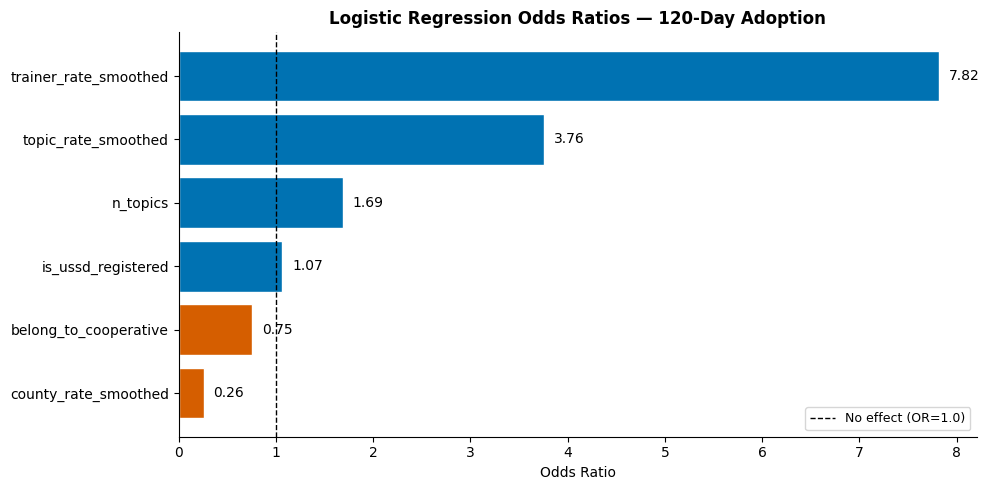

In [59]:
# ── Odds ratio chart for 120-day target ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Get 120d odds ratios
model_120  = lr_results['adopted_within_120_days']['model']
odds_120   = np.exp(model_120.coef_[0])
odds_series = pd.Series(odds_120, index=FEATURE_COLS).sort_values()

# Colour bars — above 1.0 is positive association
colours = [BLUE if v >= 1.0 else VERMILLION for v in odds_series]

bars = ax.barh(
    range(len(odds_series)),
    odds_series.values,
    color=colours,
    edgecolor='white'
)

# Add value labels
for bar, val in zip(bars, odds_series.values):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', fontsize=10
    )

ax.set_yticks(range(len(odds_series)))
ax.set_yticklabels(odds_series.index, fontsize=10)
ax.axvline(x=1.0, color='black', linestyle='--',
           linewidth=1, label='No effect (OR=1.0)')
ax.set_xlabel('Odds Ratio', fontsize=10)
ax.set_title('Logistic Regression Odds Ratios — 120-Day Adoption',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/06_odds_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Decision Tree

A decision tree learns explicit yes/no rules that split farmers into 
groups of increasing adoption probability. Unlike logistic regression 
it makes no assumption about linearity — it can capture threshold 
effects and interactions between features.

We limit the tree to four levels of depth to keep it interpretable 
and avoid overfitting on a small number of adoption events.

In [71]:
# ── 5. Decision Tree ──────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# Store results for Section 7 comparison
dt_results = {}

for target in TARGET_COLS:

    # max_depth=4      — shallow enough to visualise and explain
    # class_weight     — handles imbalance same as logistic regression
    # random_state     — reproducibility
    model = DecisionTreeClassifier(
        max_depth    = 4,
        class_weight = 'balanced',
        random_state = RANDOM_SEED
    )

    # Decision trees do not require scaling
    # We use original unscaled features here
    model.fit(X_train, y_train[target])

    val_probs = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val[target], val_probs)

    dt_results[target] = {
        'model'     : model,
        'val_probs' : val_probs,
        'auc'       : auc
    }

    print(f"{target}")
    print(f"  AUC-ROC: {auc:.4f}")
    print()

adopted_within_07_days
  AUC-ROC: 0.8726

adopted_within_90_days
  AUC-ROC: 0.8798

adopted_within_120_days
  AUC-ROC: 0.8825



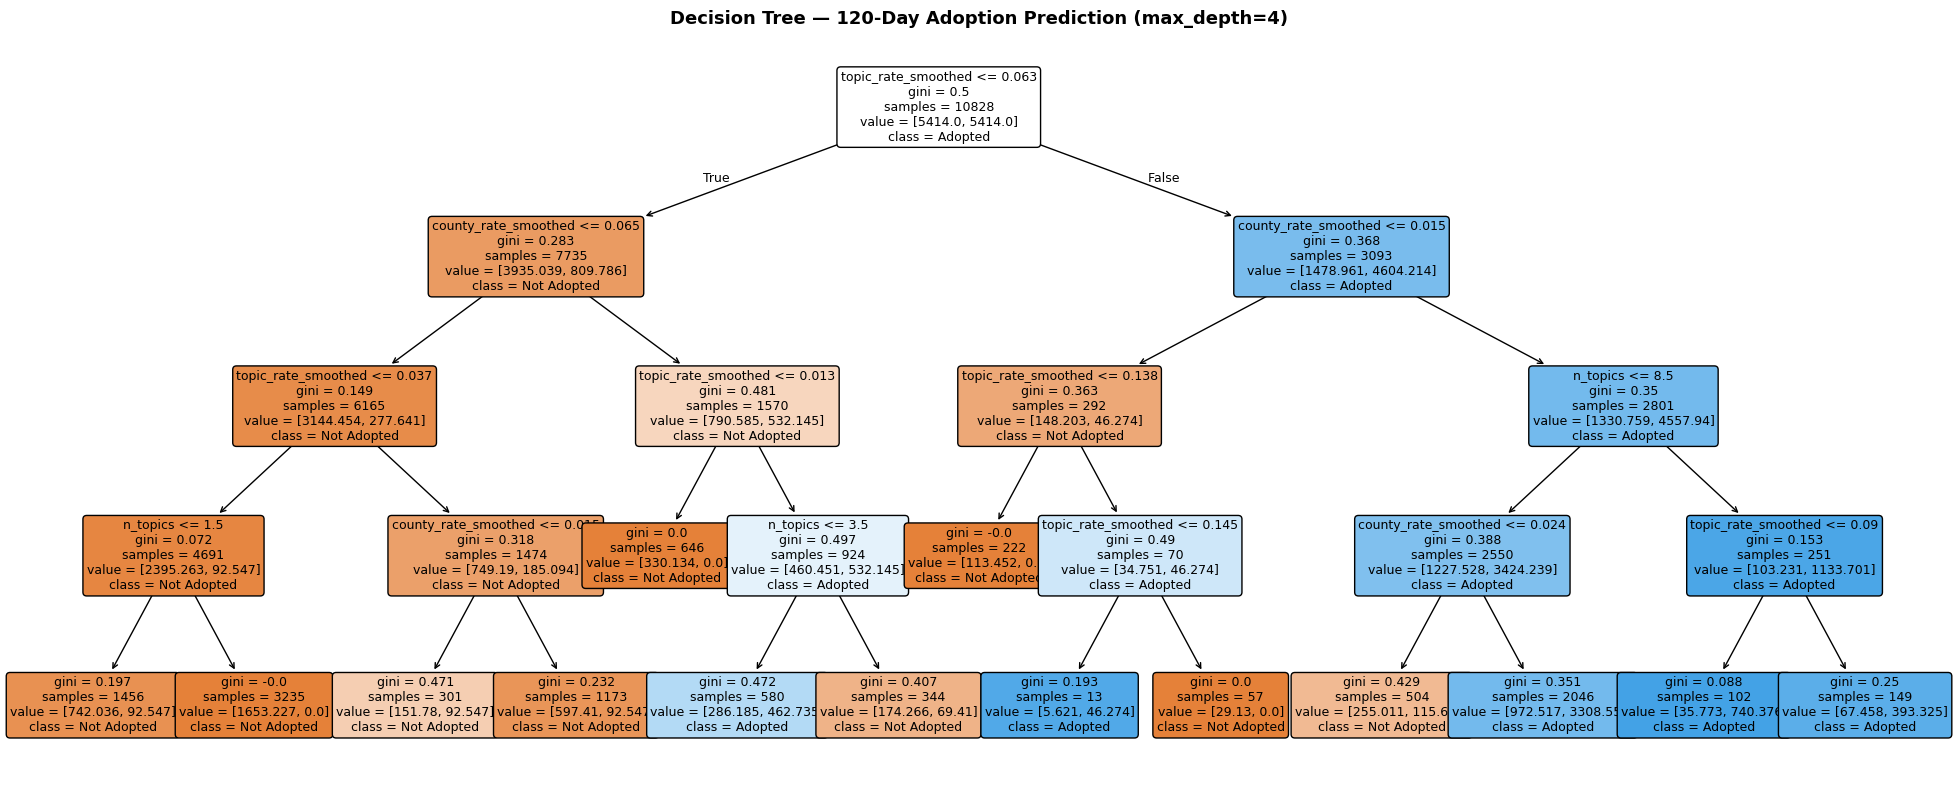

Tree saved to figures/07_decision_tree.png


In [72]:
# ── Decision tree visualisation ───────────────────────────────────────────────
from sklearn.tree import plot_tree

# Visualise the 120-day tree — most adoptions, most stable splits
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    dt_results['adopted_within_120_days']['model'],
    feature_names = FEATURE_COLS,
    class_names   = ['Not Adopted', 'Adopted'],
    filled        = True,
    rounded       = True,
    fontsize      = 9,
    ax            = ax
)

ax.set_title('Decision Tree — 120-Day Adoption Prediction (max_depth=4)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/07_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

print("Tree saved to figures/07_decision_tree.png")

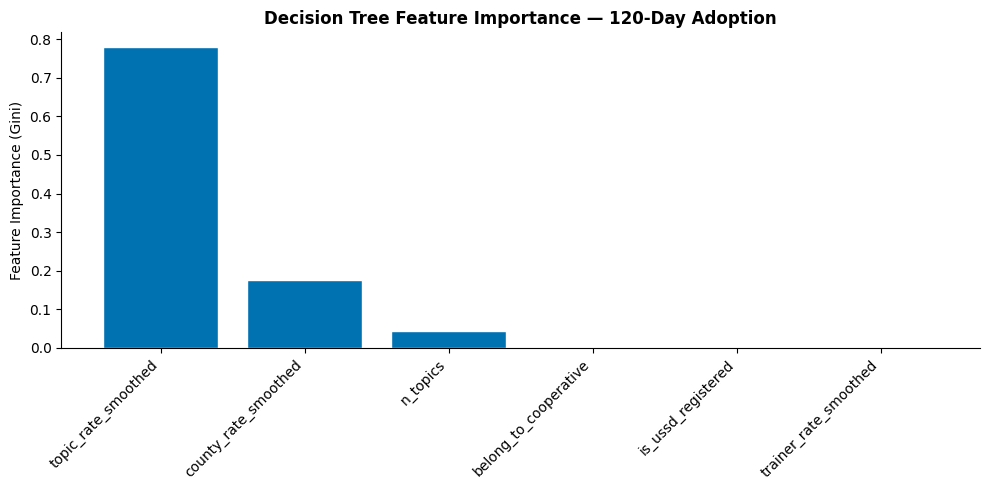


Feature importances:
topic_rate_smoothed     0.7788
county_rate_smoothed    0.1769
n_topics                0.0443
belong_to_cooperative   0.0000
is_ussd_registered      0.0000
trainer_rate_smoothed   0.0000
dtype: float64


In [73]:
# ── Feature importance from decision tree ─────────────────────────────────────
# Feature importance = how much each feature reduces impurity across all splits
# Higher value = more important for making predictions

importances = pd.Series(
    dt_results['adopted_within_120_days']['model'].feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    range(len(importances)),
    importances.values,
    color=BLUE,
    edgecolor='white'
)

ax.set_xticks(range(len(importances)))
ax.set_xticklabels(importances.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Feature Importance (Gini)', fontsize=10)
ax.set_title('Decision Tree Feature Importance — 120-Day Adoption',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importances:")
print(importances.round(4))

Topic content dominates the decision tree with 77.9% of total feature 
importance. County rate accounts for a further 17.7%. Notably trainer 
rate, cooperative membership and registration method contribute zero 
importance. The tree captures all necessary information through topic 
content and county alone. This contrasts with logistic regression where 
trainer rate was the strongest predictor, suggesting these two features 
share overlapping information that each model resolves differently.

In [76]:
# ── 6. Classifier Chain ───────────────────────────────────────────────────────
from sklearn.multioutput import ClassifierChain

# Base estimator 
base_model = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 1000,
    random_state = RANDOM_SEED
)

# order=[2, 1, 0] means:
# First  predict index 2 -> adopted_within_120_days (most cases)  
# Second predict index 1 -> adopted_within_90_days
# Third  predict index 0 ->a adopted_within_07_days (fewest cases)
chain = ClassifierChain(
    estimator = base_model,
    order = [2, 1, 0],
    random_state = RANDOM_SEED
)

# Fit on all three targets simultaneously
# Y contains all three target columns
chain.fit(X_train_scaled, y_train)

# Predict probabilities for all three targets at once
# Returns array of shape (n_samples, 3)
chain_probs = chain.predict_proba(X_val_scaled)

# Calculate AUC for each target
chain_results = {}

for i, target in enumerate(TARGET_COLS):
    auc = roc_auc_score(y_val[target], chain_probs[:, i])
    chain_results[target] = {
        'val_probs' : chain_probs[:, i],
        'auc'       : auc
    }
    print(f"{target}")
    print(f"  AUC-ROC: {auc:.4f}")
    print()

adopted_within_07_days
  AUC-ROC: 0.9128

adopted_within_90_days
  AUC-ROC: 0.8832

adopted_within_120_days
  AUC-ROC: 0.8601



## 7. Model Comparison

We compare AUC-ROC scores across all three models for each prediction 
target. No single model wins on every target, understanding where each 
model performs better informs which approach to use in practice.

In [ ]:
# ── 7. Model comparison table ─────────────────────────────────────────────────
comparison_data = []

for target in TARGET_COLS:
    label = target.replace('adopted_within_', '').replace('_days', 'd')
    comparison_data.append({
        'Target'              : label,
        'Logistic Regression' : round(lr_results[target]['auc'], 4),
        'Decision Tree'       : round(dt_results[target]['auc'], 4),
        'Classifier Chain'    : round(chain_results[target]['auc'], 4)
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Target')

print("AUC-ROC Comparison Across Models")
print("Higher is better - 0.5 = random, 1.0 = perfect")
print()
display(comparison_df)

# Highlight best model per target
print("\nBest model per target:")
for target in comparison_df.index:
    best_model = comparison_df.loc[target].idxmax()
    best_score = comparison_df.loc[target].max()
    print(f"  {target}: {best_model} ({best_score:.4f})")

AUC-ROC Comparison Across Models
Higher is better — 0.5 = random, 1.0 = perfect



,Logistic Regression,Decision Tree,Classifier Chain
Target,,,
07d,0.9144,0.8726,0.9128
90d,0.8597,0.8798,0.8832
120d,0.8601,0.8825,0.8601



Best model per target:
  07d: Logistic Regression (0.9144)
  90d: Classifier Chain (0.8832)
  120d: Decision Tree (0.8825)


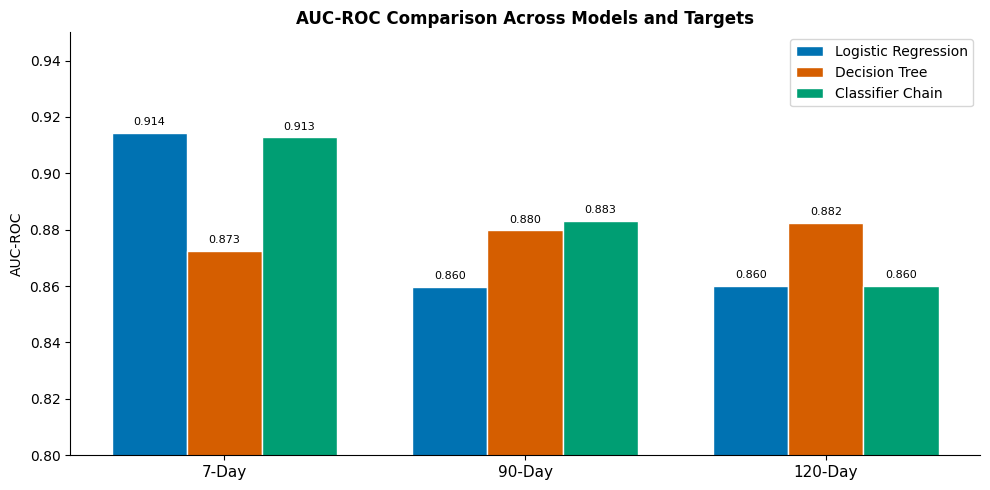

In [78]:
# ── Comparison chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

targets = ['07d', '90d', '120d']
x = np.arange(len(targets))
bar_width = 0.25

# Three groups of bars
bars1 = ax.bar(x - bar_width, comparison_df['Logistic Regression'],
               bar_width, label='Logistic Regression',
               color=BLUE, edgecolor='white')

bars2 = ax.bar(x, comparison_df['Decision Tree'],
               bar_width, label='Decision Tree',
               color=VERMILLION, edgecolor='white')

bars3 = ax.bar(x + bar_width, comparison_df['Classifier Chain'],
               bar_width, label='Classifier Chain',
               color=GREEN, edgecolor='white')

# Value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(['7-Day', '90-Day', '120-Day'], fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=10)
ax.set_ylim(0.8, 0.95)
ax.set_title('AUC-ROC Comparison Across Models and Targets',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

No single model dominates across all three targets. Logistic regression 
performs best for short-window prediction (7 days, AUC=0.914), 
suggesting that cooperative membership and registration method
(linear predictors) are most relevant for immediate adoption. The 
classifier chain improves 90-day prediction by conditioning on the 
120-day estimate. The decision tree performs best for 120-day 
prediction, capturing non-linear threshold effects in topic content 
and county rates that logistic regression misses.

All three models substantially outperform random guessing (AUC=0.5), 
demonstrating that farmer characteristics available at training time 
contain genuine signal about future adoption behaviour.

## 8. Interpretation and Recommendations

### What the Models Found

Across all three models and prediction windows, two features consistently 
emerged as the strongest predictors of farmer adoption:

**Trainer quality** (trainer_rate_smoothed) was the dominant predictor 
in logistic regression with an odds ratio of 7.82 for 120-day adoption. 
Farmers trained by historically effective trainers are nearly eight times 
more likely to adopt compared to farmers trained by the least effective 
trainers, holding all other factors constant.

**Topic content** (topic_rate_smoothed) dominated the decision tree with 
77.9% of total feature importance. Health-focused topics such as poultry 
health management, deworming and vaccination consistently show the highest 
adoption rates — often exceeding 10% compared to the overall rate of 2.23%.

### Practical Recommendations for DigiCow

**1. Prioritise trainer development**

The single most impactful lever for improving adoption rates is trainer 
quality. The difference between the best and worst performing trainers 
is a 37x difference in adoption rates. Identifying what effective 
trainers do differently and replicating those practices across all 
trainers could substantially increase overall adoption.

**2. Prioritise health-focused training content**

Sessions covering animal health topics consistently outperform 
agronomic topics. Where possible, DigiCow should weight training 
content toward health interventions — particularly topics with 
demonstrated high adoption rates such as poultry health, deworming 
and vaccination.

**3. Target USSD-registered farmers for follow-up**

USSD-registered farmers adopt at three times the rate of manually 
registered farmers. This group may be more digitally engaged and 
receptive to follow-up through digital channels.

**4. Focus retention efforts on cooperative members**

While cooperative membership showed a positive raw association with 
adoption, after controlling for trainer and topic quality the 
relationship reversed. This suggests cooperative members in low-quality 
training environments are underperforming their potential. Implementing targeted intervention in these groups could yield high returns.

### Limitations

- Models were trained on a single geographic area covering 8 counties 
  and 9 trainers.